# WORKSHOP 1
# NAME : Sanjai S
# REG NO : 212223230185

In [2]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt



Face image shape: (1254, 1254, 3)


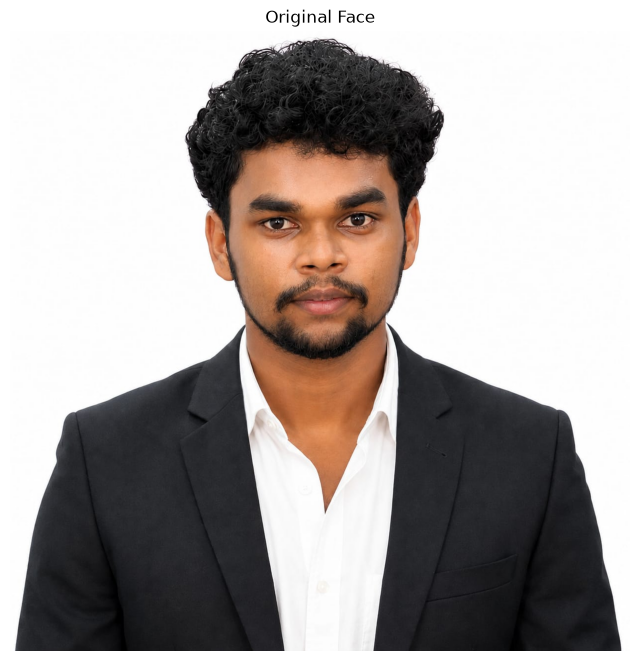

In [3]:

# ============================================================
# 2. LOAD FACE IMAGE
# ============================================================

faceImage = cv2.imread("sanjaisan.jpeg")

print("Face image shape:", faceImage.shape)

plt.figure(figsize=(8, 10))
plt.imshow(cv2.cvtColor(faceImage, cv2.COLOR_BGR2RGB))
plt.title("Original Face")
plt.axis("off")
plt.show()



Original sunglasses shape: (231, 433, 4)


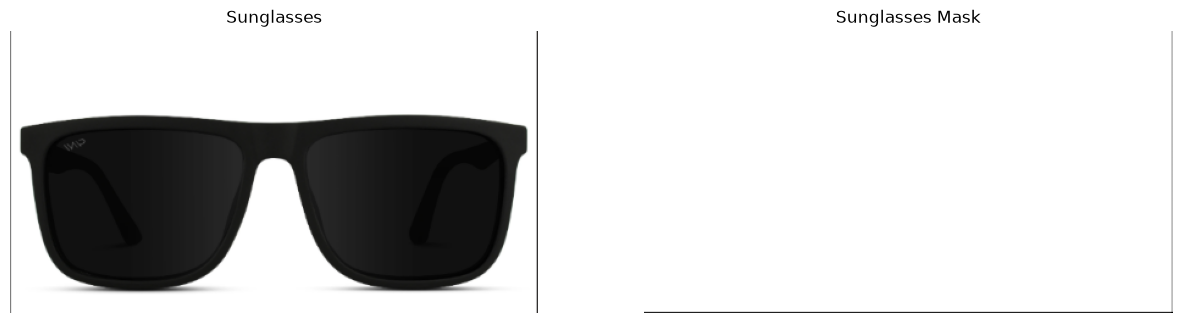

In [4]:

# ============================================================
# 3. LOAD SUNGLASSES IMAGE WITH ALPHA CHANNEL
# ============================================================

glassPNG = cv2.imread("glass1.png", cv2.IMREAD_UNCHANGED)

print("Original sunglasses shape:", glassPNG.shape)


# ============================================================
# 4. SEPARATE COLOR AND ALPHA CHANNEL
# ============================================================

if glassPNG.shape[2] == 4:

    # PNG has an alpha channel
    glassBGR = glassPNG[:, :, :3]
    glassMask1 = glassPNG[:, :, 3]

else:

    # PNG has no alpha channel
    print("WARNING: glass.png does not have an alpha channel.")

    glassBGR = glassPNG

    # Create a mask from non-black pixels
    gray = cv2.cvtColor(glassBGR, cv2.COLOR_BGR2GRAY)
    _, glassMask1 = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)


# Display sunglasses and mask

plt.figure(figsize=(15, 6))

plt.subplot(121)
plt.imshow(cv2.cvtColor(glassBGR, cv2.COLOR_BGR2RGB))
plt.title("Sunglasses")
plt.axis("off")

plt.subplot(122)
plt.imshow(glassMask1, cmap="gray")
plt.title("Sunglasses Mask")
plt.axis("off")

plt.show()




In [5]:
# ============================================================
# 5. CROP EMPTY AREA AROUND THE SUNGLASSES
# ============================================================

# Find pixels belonging to the sunglasses
ys, xs = np.where(glassMask1 > 0)

if len(xs) == 0:
    raise ValueError("The sunglasses mask is empty.")

# Bounding box
x_min = xs.min()
x_max = xs.max()
y_min = ys.min()
y_max = ys.max()

print("Sunglasses bounding box:")
print("x:", x_min, "to", x_max)
print("y:", y_min, "to", y_max)


# Crop both image and mask
glassBGR = glassBGR[y_min:y_max+1, x_min:x_max+1]
glassMask1 = glassMask1[y_min:y_max+1, x_min:x_max+1]

print("Cropped sunglasses:", glassBGR.shape)


# ============================================================
# 6. CREATE THE FACE IMAGE FOR OVERLAY
# ============================================================

faceWithGlassesNaive = faceImage.copy()


# ============================================================
# 7. CHOOSE THE SUNGLASSES POSITION
# ============================================================

# Your face image is 1065 wide x 1280 high.
#
# The eyes/glasses are approximately in this area:
#
# x: 350 -> 900
# y: 380 -> 570
#
# We place the sunglasses slightly above the center.

x1 = 300
y1 = 360

# Width of the sunglasses on the face
new_width = 620


# ============================================================
# 8. RESIZE SUNGLASSES WHILE KEEPING ASPECT RATIO
# ============================================================

original_height, original_width = glassBGR.shape[:2]

new_height = int(
    original_height * new_width / original_width
)

glassBGR_resized = cv2.resize(
    glassBGR,
    (new_width, new_height),
    interpolation=cv2.INTER_AREA
)

glassMask1_resized = cv2.resize(
    glassMask1,
    (new_width, new_height),
    interpolation=cv2.INTER_NEAREST
)

print("Resized sunglasses:", glassBGR_resized.shape)


Sunglasses bounding box:
x: 0 to 432
y: 0 to 230
Cropped sunglasses: (231, 433, 3)
Resized sunglasses: (330, 620, 3)


In [6]:


# ============================================================
# 9. CHECK THAT SUNGLASSES FIT INSIDE FACE IMAGE
# ============================================================

face_height, face_width = faceImage.shape[:2]

if x1 + new_width > face_width:
    raise ValueError("Sunglasses extend beyond the right side of the face image.")

if y1 + new_height > face_height:
    raise ValueError("Sunglasses extend beyond the bottom of the face image.")


# ============================================================
# 10. GET THE FACE REGION
# ============================================================

eyeROI = faceWithGlassesNaive[
    y1:y1+new_height,
    x1:x1+new_width
]

print("Face ROI:", eyeROI.shape)
print("Glass:", glassBGR_resized.shape)


# ============================================================
# 11. CREATE 3-CHANNEL MASK
# ============================================================

glassMask = cv2.merge(
    (
        glassMask1_resized,
        glassMask1_resized,
        glassMask1_resized
    )
)


# Convert mask from [0,255] to [0,1]

glassMask = glassMask.astype(np.float32) / 255.0


# ============================================================
# 12. MASK THE FACE REGION
# ============================================================

maskedEye = cv2.multiply(
    eyeROI.astype(np.float32),
    1 - glassMask
)


# ============================================================
# 13. MASK THE SUNGLASSES
# ============================================================

maskedGlass = cv2.multiply(
    glassBGR_resized.astype(np.float32),
    glassMask
)


# ============================================================
# 14. COMBINE FACE + SUNGLASSES
# ============================================================

eyeRoiFinal = cv2.add(
    maskedEye,
    maskedGlass
)

eyeRoiFinal = np.uint8(eyeRoiFinal)




Face ROI: (330, 620, 3)
Glass: (330, 620, 3)


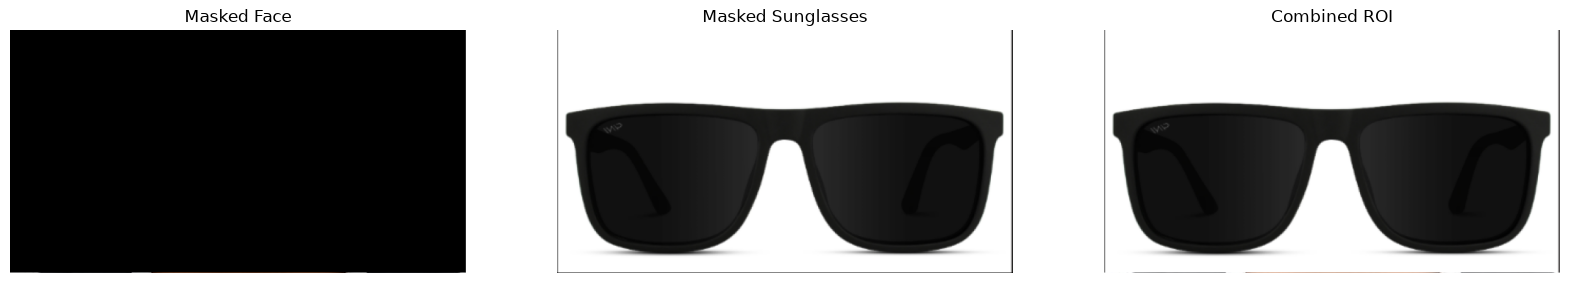

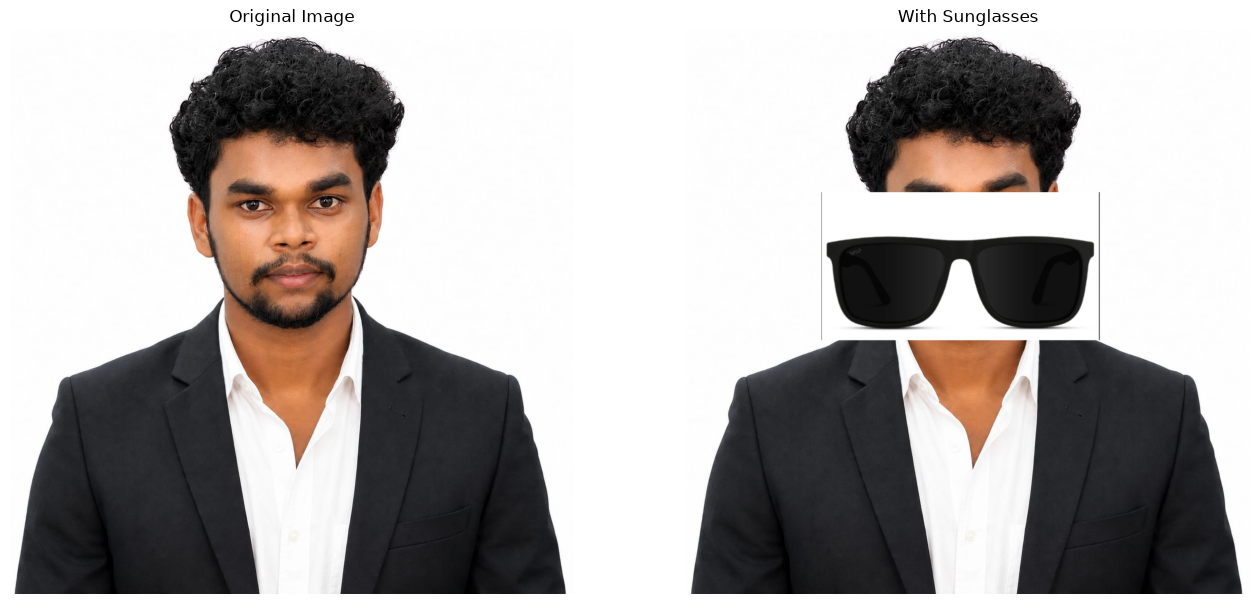

In [7]:
# ============================================================
# 15. PUT THE RESULT BACK INTO THE FACE IMAGE
# ============================================================

faceWithGlassesNaive[
    y1:y1+new_height,
    x1:x1+new_width
] = eyeRoiFinal


# ============================================================
# 16. DISPLAY INTERMEDIATE RESULTS
# ============================================================

plt.figure(figsize=(20, 6))

plt.subplot(131)
plt.imshow(cv2.cvtColor(np.uint8(maskedEye), cv2.COLOR_BGR2RGB))
plt.title("Masked Face")
plt.axis("off")

plt.subplot(132)
plt.imshow(cv2.cvtColor(np.uint8(maskedGlass), cv2.COLOR_BGR2RGB))
plt.title("Masked Sunglasses")
plt.axis("off")

plt.subplot(133)
plt.imshow(cv2.cvtColor(eyeRoiFinal, cv2.COLOR_BGR2RGB))
plt.title("Combined ROI")
plt.axis("off")

plt.show()


# ============================================================
# 17. DISPLAY FINAL RESULT
# ============================================================

plt.figure(figsize=(16, 8))

plt.subplot(121)
plt.imshow(cv2.cvtColor(faceImage, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(122)
plt.imshow(cv2.cvtColor(faceWithGlassesNaive, cv2.COLOR_BGR2RGB))
plt.title("With Sunglasses")
plt.axis("off")

plt.show()